# ĐỒ ÁN MÔN HỌC TRÍ TUỆ NHÂN TẠO (CS106)

## ĐỀ TÀI 10: Xây dựng hệ thống giao dịch tiền mã hóa với tầng meta-labeling bằng CatBoost, thông qua đó đánh giá ảnh hưởng của phương pháp chia dữ liệu đến độ tin cậy của kết quả kiểm định.



* **Trường Đại học Công nghệ Thông tin (UIT) — ĐHQG-HCM**

* **Khoa Khoa học Máy tính**

* **Giảng viên hướng dẫn:** TS. Nguyễn Đình Hiển

* **Nhóm sinh viên thực hiện:** Nhóm 11



---

### Tóm tắt nội dung đồ án

1. **Bài toán:** Xây dựng hệ thống giao dịch định lượng 2 tầng cho cặp BTCUSD (khung M15): Tầng 1 là chiến lược theo xu hướng Pyramid, Tầng 2 là mô hình học máy **CatBoost** đóng vai trò tầng **Meta-Labeling** thẩm định chất lượng tín hiệu.

2. **Trọng tâm phương pháp luận:** Thực nghiệm đo lường định lượng ảnh hưởng của **4 phương pháp phân chia dữ liệu** (Random K-Fold, Grouped K-Fold, Walk-Forward, Purged & Embargoed Walk-Forward) đến độ tin cậy của kết quả kiểm định.

3. **Kiểm chứng độc lập:** Đối soát kết quả với tập dữ liệu tương lai niêm phong (**Sealed Holdout 5.028 mẫu**).



> ### Môi trường thực thi

> Notebook chạy trên **kernel `citd-ml`** do `uv` quản lý (Python 3.12 trong `.venv/` của dự án).

> Thiết lập một lần: `uv sync --extra dev` rồi

> `uv run python -m ipykernel install --prefix .venv --name citd-ml --display-name "Python 3.12 (citd-ml)"`.

> Xem mục *Environment setup* trong [`README.md`](README.md).

> Notebook **không** cần file thô `data/raw/BTCUSD_m1_2018_to_now.csv` (~209 MB) — mọi ô chỉ đọc dữ liệu đã xử lý và kết quả đã commit trong `outputs/`.


In [1]:
# ======================================================================
# Ô 1 — KHỞI TẠO MÔI TRƯỜNG THỰC THI (uv / kernel citd-ml)
# ======================================================================
import os
import sys
import platform
from pathlib import Path
from importlib import metadata as _pkg_metadata

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import Image, display
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, roc_curve, confusion_matrix)
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier

# Cấu hình hiển thị biểu đồ: DejaVu Sans có đủ dấu tiếng Việt, tắt dấu trừ Unicode
# (nếu không matplotlib sẽ cảnh báo 'missing from font' ở mọi nhãn tiếng Việt).
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
matplotlib.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

# --- Định vị thư mục gốc của dự án -------------------------------------
# Tìm theo 'file đánh dấu' để không phụ thuộc thư mục làm việc của Jupyter.
MARKER = Path('data/processed/dataset_catboost.csv')

def _locate_root() -> Path:
    here = Path.cwd().resolve()
    candidates = [here, here / 'citd-ml-project', here.parent, here.parent / 'citd-ml-project']
    for candidate in candidates:
        if (candidate / MARKER).is_file():
            return candidate
    probe = here
    while probe != probe.parent:
        for base in (probe, probe / 'citd-ml-project'):
            if (base / MARKER).is_file():
                return base
        probe = probe.parent
    raise FileNotFoundError(
        'Không tìm thấy thư mục dự án chứa ' + str(MARKER) + '. '
        'Hãy mở notebook từ gốc repo hoặc chạy: uv run jupyter lab'
    )

ROOT = _locate_root()

# Đưa src/ vào sys.path để dùng được package citd_ml khi chưa cài editable.
if (ROOT / 'src').is_dir() and str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

from citd_ml import paths as citd_paths

# paths.py là nguồn sự thật duy nhất; nó phải trùng với thư mục vừa dò được.
if citd_paths.PROJECT_ROOT.resolve() != ROOT:
    raise RuntimeError(
        f'citd_ml.paths.PROJECT_ROOT ({citd_paths.PROJECT_ROOT}) khác ROOT dò được ({ROOT})'
    )

# --- Báo cáo môi trường để chứng minh chạy đúng kernel --------------------
def _version(name: str) -> str:
    try:
        return _pkg_metadata.version(name)
    except _pkg_metadata.PackageNotFoundError:
        return 'không cài đặt'

print('=' * 78)
print('MÔI TRƯỜNG THỰC THI CỦA NOTEBOOK')
print('=' * 78)
print(f'Python      : {sys.version.split()[0]}  ({sys.executable})')
print(f'Hệ điều hành: {platform.system()} {platform.release()} ({platform.machine()})')
for _dist in ('catboost', 'scikit-learn', 'pandas', 'numpy', 'plotly', 'matplotlib'):
    print(f'{_dist:<12}: {_version(_dist)}')
try:
    from IPython import get_ipython
    print(f'Kernel      : {get_ipython().kernel.__class__.__name__}')
    print(f'jupyterlab  : {_version("jupyterlab")}')
except Exception:
    print('Kernel      : (đang chạy ngoài Jupyter)')
print(f'Thư mục gốc : {ROOT}')

# Kernel phải nằm trong .venv của chính dự án này, nếu không sẽ thiếu catboost.
if Path(sys.prefix).resolve() != (ROOT / '.venv').resolve():
    raise RuntimeError(
        f'Kernel đang dùng {sys.prefix}, không phải {ROOT / ".venv"}. '
        'Hãy chọn kernel "Python 3.12 (citd-ml)" (xem mục Environment setup trong README).'
    )
print('=> Kernel đúng môi trường uv của dự án (.venv).')
print('=' * 78)


MÔI TRƯỜNG THỰC THI CỦA NOTEBOOK
Python      : 3.12.14  (/home/thanhnndev/develop/citd-ml-project/.venv/bin/python3)
Hệ điều hành: Linux 7.2.7-1-cachyos (x86_64)
catboost    : 1.2.10
scikit-learn: 1.9.0
pandas      : 3.0.5
numpy       : 2.5.2
plotly      : 7.0.0
matplotlib  : 3.11.2
Kernel      : IPythonKernel
jupyterlab  : 4.6.4
Thư mục gốc : /home/thanhnndev/develop/citd-ml-project
=> Kernel đúng môi trường uv của dự án (.venv).


In [2]:
# ======================================================================
# Ô 2 — HẰNG SỐ ĐÓNG BĂNG + KIỂM TRA SỚ CẦN THIẾT
# ======================================================================
# 23 đặc trưng: thứ tự này phải khớp với thứ tự CatBoost đã huấn luyện.
FEATURES = [
    'breakeven_R', 'atr14_pct', 'atr_ratio_14_90', 'vol20', 'vol200', 'vol_ratio_20_200',
    'range_pct', 'dist_ema20_atr', 'dist_ema50_atr', 'dist_ema200_atr', 'ret20_atr', 'ret50_atr',
    'pos_in_range50', 'dist_hh20_atr', 'mom14', 'mom_diff', 'vwap_dist_atr', 'vwap_slope_atr',
    'rsi14', 'vol_ratio_volume', 'gap_open_atr', 'hour', 'dow'
]

# Nhãn là 2 giá trị: 0 = thua / hết giờ, 1 = thắng
TARGET = 'label'

# Biên 5 khúc (chunk) — chính là biên được đóng băng trong README và trong
# src/citd_ml/training/pre_train.py (edges = [n*k//5 for k in range(6)]).
# Sẽ được đối chiếu lại ở Ô 3 chứ không hard-code giá trị đã dịch.
EXPECTED_CHUNK_EDGES = [0, 5001, 10003, 15004, 20006, 25008]

REQUIRED_ARTIFACTS = [
    'data/processed/dataset_catboost.csv',
    'outputs/holdout/stage3/holdout_scored.csv',
    'outputs/holdout/stage2/catboost_final_holdout_run1.cbm',
    'outputs/holdout/stage4/table1_classification_metrics.csv',
    'outputs/holdout/stage4/table2_financial_metrics_top50.csv',
    'outputs/holdout/stage4/equity-curve-chunk2-5-top50.png',
    'outputs/holdout/stage4/equity-curve-holdout-top50.png',
    'outputs/step4_thread1/catboost_training/oof_random_kfold.csv',
    'outputs/step4_thread1/catboost_training/oof_grouped_kfold.csv',
    'outputs/step4_thread1/catboost_training/oof_walk_forward.csv',
    'outputs/step4_thread1/catboost_training/oof_purged_walk_forward.csv',
]

DATASET_CSV = ROOT / 'data/processed/dataset_catboost.csv'
HOLDOUT_SCORED_CSV = ROOT / 'outputs/holdout/stage3/holdout_scored.csv'
HOLDOUT_MODEL_CBM = ROOT / 'outputs/holdout/stage2/catboost_final_holdout_run1.cbm'
STAGE4_DIR = ROOT / 'outputs/holdout/stage4'
CANONICAL_OOF_DIR = ROOT / 'outputs/step4_thread1/catboost_training'

_missing = [rel for rel in REQUIRED_ARTIFACTS if not (ROOT / rel).is_file()]
if _missing:
    raise FileNotFoundError(
        'Thiếu ' + str(len(_missing)) + ' tệp kết quả cần cho notebook:\n  - '
        + '\n  - '.join(_missing)
        + '\n\nHãy chạy `uv sync --extra dev` và giữ nguyên thư mục outputs/ của repo.'
    )

print(f'Đã kiểm tra {len(REQUIRED_ARTIFACTS)} tệp kết quả: tất cả đều tồn tại.')
print(f'{len(FEATURES)} đặc trưng đầu vào, mốc chia khúc = {EXPECTED_CHUNK_EDGES}')


Đã kiểm tra 11 tệp kết quả: tất cả đều tồn tại.
23 đặc trưng đầu vào, mốc chia khúc = [0, 5001, 10003, 15004, 20006, 25008]


---
## PHẦN 1: KHÁM PHÁ VÀ PHÂN TÍCH DỮ LIỆU (EDA)
Bộ dữ liệu gồm:
* **Tập Huấn luyện & Phát triển (Train/Dev):** 25.008 mẫu giao dịch (giai đoạn 2018 – đầu 2025).
* **Tập Kiểm định độc lập niêm phong (Sealed Holdout):** 5.028 mẫu giao dịch (08/02/2025 – 21/08/2026).
* Mỗi mẫu có **23 đặc trưng kỹ thuật (`FEATURES`)** thuộc 4 nhóm: Động lượng, Biến động, Xu hướng và Khối lượng/Cấu trúc lệnh.

Tập holdout ở đây là **tập đã được chấm điểm sẵn** (`outputs/holdout/stage3/holdout_scored.csv`), nên nó chỉ dùng để *kiểm chứng lại* kết quả đã công bố — không huấn luyện hay tinh chỉnh gì trên tập này.


In [3]:
# Nạp dữ liệu huấn luyện và tập kiểm định holdout
df_train = pd.read_csv(DATASET_CSV)
df_holdout = pd.read_csv(HOLDOUT_SCORED_CSV)

print(f'Kích thước tập Train/Dev: {df_train.shape[0]:,} dòng, {df_train.shape[1]} cột')
print(f'Kích thước tập Holdout:   {df_holdout.shape[0]:,} dòng, {df_holdout.shape[1]} cột')
print(f'Kiểm tra giá trị thiếu (Missing values): {df_train.isna().sum().sum()} ô')

# Kiểm tra chặt: dừng ngay nếu dữ liệu lệch so với đặc tả bàn giao.
_problems = []
if len(df_train) != 25008:
    _problems.append(f'Train phải có 25.008 dòng, thực tế {len(df_train):,}')
if len(df_holdout) != 5028:
    _problems.append(f'Holdout phải có 5.028 dòng, thực tế {len(df_holdout):,}')
if len(FEATURES) != 23:
    _problems.append(f'Phải có 23 đặc trưng, thực tế {len(FEATURES)}')
for _name, _frame in (('Train', df_train), ('Holdout', df_holdout)):
    _absent = [c for c in FEATURES if c not in _frame.columns]
    if _absent:
        _problems.append(f'{_name} thiếu cột: {_absent}')
    if _frame[FEATURES].isna().any().any():
        _problems.append(f'{_name} có NaN trong 23 đặc trưng')
    _bad_label = set(_frame[TARGET].dropna().unique()) - {0, 1}
    if _bad_label:
        _problems.append(f'{_name} có nhãn ngoài {{0,1}}: {_bad_label}')
if 'probability' not in df_holdout.columns:
    _problems.append("Holdout thiếu cột 'probability' (chưa chấm điểm)")
if _problems:
    raise ValueError('Dữ liệu không khớp đặc tả:\n  - ' + '\n  - '.join(_problems))

print('\nKiểm tra dữ liệu: OK (23 đặc trưng, nhãn nhị phân, không có NaN)')
print(f"Tỷ lệ nhãn=1 — Train: {df_train[TARGET].mean():.2%} | Holdout: {df_holdout[TARGET].mean():.2%}")
df_train[FEATURES].head(3)


Kích thước tập Train/Dev: 25,008 dòng, 31 cột
Kích thước tập Holdout:   5,028 dòng, 32 cột
Kiểm tra giá trị thiếu (Missing values): 0 ô

Kiểm tra dữ liệu: OK (23 đặc trưng, nhãn nhị phân, không có NaN)
Tỷ lệ nhãn=1 — Train: 26.16% | Holdout: 28.04%


,breakeven_R,atr14_pct,atr_ratio_14_90,vol20,vol200,vol_ratio_20_200,range_pct,dist_ema20_atr,dist_ema50_atr,dist_ema200_atr,...,dist_hh20_atr,mom14,mom_diff,vwap_dist_atr,vwap_slope_atr,rsi14,vol_ratio_volume,gap_open_atr,hour,dow
0,3.996264,0.005501,0.871953,0.004540,0.006401,0.709329,0.005012,1.867696,2.232804,7.045843,...,-0.221420,102.058714,-0.162801,4.245061,0.124518,70.993523,1.235649,-0.016847,0,3
1,4.036220,0.005256,0.824889,0.004688,0.006404,0.732076,0.006609,1.029009,1.461486,6.515285,...,-1.058824,100.845526,-1.213189,3.512437,0.124054,59.303527,0.872390,-0.035421,0,3
2,4.039321,0.005472,0.857613,0.004640,0.006403,0.724659,0.006146,1.178130,1.649531,6.497789,...,-0.699939,101.020538,0.175013,3.563433,0.120142,60.815804,0.938807,0.064293,0,3


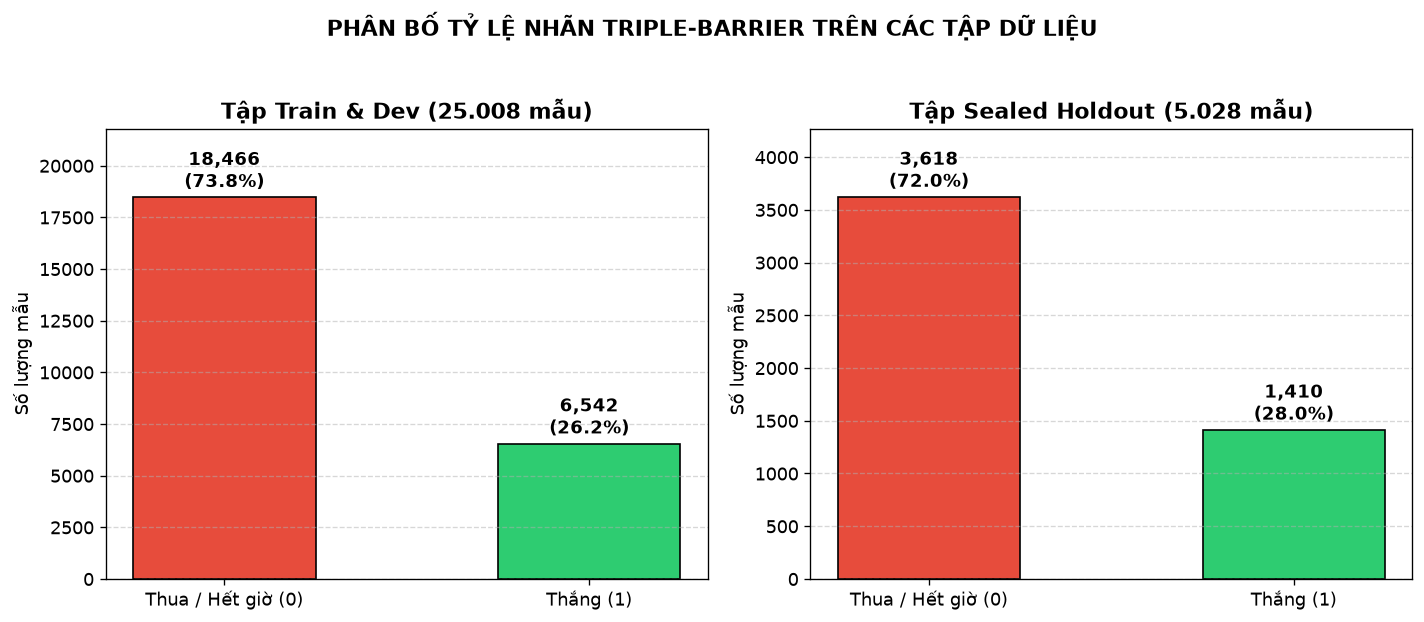

In [4]:
# Trực quan hóa tỷ lệ phân bố nhãn (Class Distribution)
fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=120)

for idx, (df, name) in enumerate([(df_train, 'Tập Train & Dev (25.008 mẫu)'),
                                   (df_holdout, 'Tập Sealed Holdout (5.028 mẫu)')]):
    counts = df[TARGET].value_counts().sort_index()
    pcts = counts / len(df) * 100
    bars = axes[idx].bar(['Thua / Hết giờ (0)', 'Thắng (1)'], counts,
                          color=['#E74C3C', '#2ECC71'], width=0.5, edgecolor='black')
    axes[idx].set_title(name, fontweight='bold')
    axes[idx].set_ylabel('Số lượng mẫu')
    axes[idx].set_ylim(0, max(counts) * 1.18)
    axes[idx].grid(axis='y', linestyle='--', alpha=0.5)
    for bar, count, pct in zip(bars, counts, pcts):
        axes[idx].text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + len(df) * 0.02,
                        f'{count:,}\n({pct:.1f}%)', ha='center', fontweight='bold')

plt.suptitle('PHÂN BỐ TỶ LỆ NHÃN TRIPLE-BARRIER TRÊN CÁC TẬP DỮ LIỆU', fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()


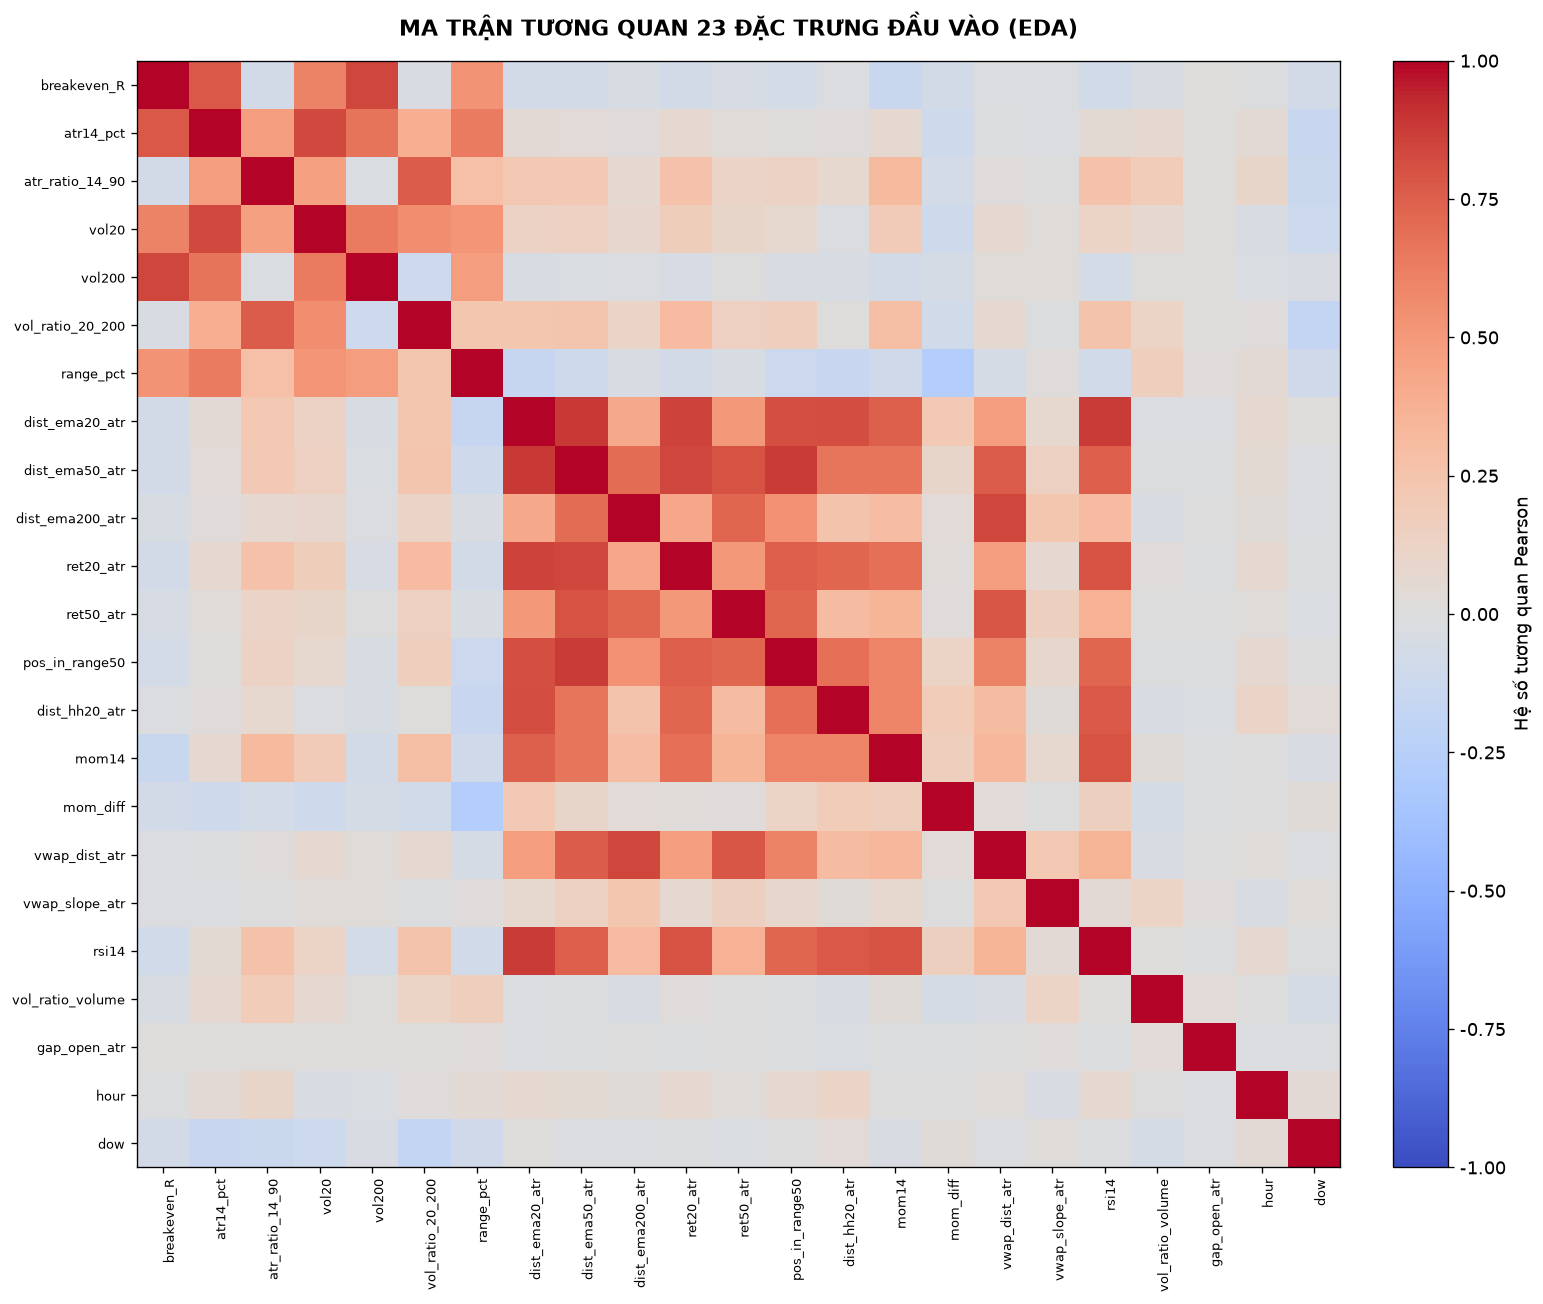

Các cặp đặc trưng tương quan mạnh nhất (|r| > 0.80):
  dist_ema20_atr  <->  dist_ema50_atr :  r = +0.8837
  dist_ema50_atr  <->  pos_in_range50 :  r = +0.8808
  dist_ema20_atr  <->  rsi14 :  r = +0.8795
  dist_ema20_atr  <->  ret20_atr :  r = +0.8527
  dist_ema200_atr  <->  vwap_dist_atr :  r = +0.8409
  breakeven_R  <->  vol200 :  r = +0.8408
  dist_ema50_atr  <->  ret20_atr :  r = +0.8395
  atr14_pct  <->  vol20 :  r = +0.8290
  dist_ema20_atr  <->  dist_hh20_atr :  r = +0.8163
  dist_ema20_atr  <->  pos_in_range50 :  r = +0.8092
  dist_ema50_atr  <->  ret50_atr :  r = +0.8044
  mom14  <->  rsi14 :  r = +0.8025


In [5]:
# Ma trận tương quan giữa 23 đặc trưng (Correlation Heatmap)
corr = df_train[FEATURES].corr()

fig, ax = plt.subplots(figsize=(13, 11), dpi=120)
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Hệ số tương quan Pearson')
ax.set_xticks(range(len(FEATURES)))
ax.set_yticks(range(len(FEATURES)))
ax.set_xticklabels(FEATURES, rotation=90, ha='left', fontsize=8)
ax.set_yticklabels(FEATURES, fontsize=8)
ax.set_title('MA TRẬN TƯƠNG QUAN 23 ĐẶC TRƯNG ĐẦU VÀO (EDA)', fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# Ghi nhận cặp tương quan mạnh nhất để tránh hiểu nhầm ý nghĩa của mô hình.
_corr = df_train[FEATURES].corr()
# Giữ mỗi cặp một lần (a < b) để không in trùng.
_pairs = _corr.abs().stack().reset_index()
_pairs.columns = ['a', 'b', 'abs_r']
_pairs = _pairs.loc[_pairs['a'] < _pairs['b']].sort_values('abs_r', ascending=False)
print('Các cặp đặc trưng tương quan mạnh nhất (|r| > 0.80):')
_strong = _pairs.loc[_pairs['abs_r'] > 0.80]
if _strong.empty:
    print('  (không có cặp nào vượt ngưỡng)')
else:
    for _row in _strong.itertuples(index=False):
        print(f'  {_row.a}  <->  {_row.b} :  r = {_corr.loc[_row.a, _row.b]:+.4f}')


---
## PHẦN 2: BỐN CHIẾN LƯỢC PHÂN CHIA DỮ LIỆU & XỬ LÝ RÒ RỈ
Đồ án thiết lập thực nghiệm so sánh 4 phương pháp phân chia dữ liệu với mức độ kỷ luật tăng dần:
1. **Cách 1 (Random K-Fold):** Trộn ngẫu nhiên (vi phạm trật tự thời gian và xé lẻ cụm `origin_bar`).
2. **Cách 1b (Grouped K-Fold):** Khóa gia đình lệnh `origin_bar` không bị xé đôi.
3. **Cách 2 (Walk-Forward):** Cắt theo dòng thời gian qua 4 bước (Expanding Window: học quá khứ đoán tương lai).
4. **Cách 3 (Purged & Embargoed Walk-Forward):** Cắt theo thời gian + Thanh lọc lệnh chồng lấn (Purging) + Vùng đệm cách ly 50 bars (Embargo).

Ô dưới đây **chạy thật** hàm chia của dự án trên bộ dữ liệu 25.008 dòng để in ra kích thước từng fold — không chỉ liệt kê tên hàm.


In [6]:
# Dựng lại bốn cách chia bằng đúng hàm của dự án và in báo cáo từng fold
from citd_ml.training.pre_train import prepare_dataset
from citd_ml.training.split_data import (make_all_folds, validate_all_folds,
                                        print_fold_report)

# prepare_dataset() là nguồn sự thật duy nhất cho thứ tự dòng, biên 5 khúc và metadata.
ds_df, X_all, y_all, meta_all, chunk_edges, chunks = prepare_dataset()

print(f'Biên 5 khúc: {chunk_edges}')
print(f'Khớp với biên đóng băng của đồ án: {chunk_edges == EXPECTED_CHUNK_EDGES}')
if chunk_edges != EXPECTED_CHUNK_EDGES:
    raise ValueError(f'Biên khúc {chunk_edges} lệch so với {EXPECTED_CHUNK_EDGES}')
print('Số dòng mỗi khúc: ' + ', '.join(str(len(c)) for c in chunks))

all_folds = make_all_folds(X_all, y_all, meta_all, chunks)
# validate_all_folds() sẽ ném lỗi nếu bất kỳ điều kiện rò rỉ nào bị vi phạm.
validate_all_folds(all_folds, meta_all, chunks, len(ds_df))

print_fold_report('Cách 1 - Random K-Fold (xé lẻ cả trật tự thời gian lẫn gia đình lệnh)',
                  all_folds['random_kfold'], y_all)
print_fold_report('Cách 1b - Grouped K-Fold (giữ trọn gia đình lệnh)',
                  all_folds['grouped_kfold'], y_all)
print_fold_report('Cách 2 - Walk-Forward (mở rộng cửa sổ theo thời gian)',
                  all_folds['walk_forward'], y_all)
print_fold_report('Cách 3 - Purged + Embargo Walk-Forward',
                  all_folds['purged_walk_forward'], y_all,
                  reference=all_folds['walk_forward'])

print('\nCột "Removed" = số dòng bị purge/embargo loại khỏi tập train của Cách 3.')
print('Kiểm tra bốn cách chia: OK')


Biên 5 khúc: [0, 5001, 10003, 15004, 20006, 25008]
Khớp với biên đóng băng của đồ án: True
Số dòng mỗi khúc: 5001, 5002, 5001, 5002, 5002

Cách 1 - Random K-Fold (xé lẻ cả trật tự thời gian lẫn gia đình lệnh)
Fold | Train | Test | Removed | Train label=1 | Test label=1
   1 | 20006 | 5002 |       0 |      26.2521% |     25.7897%
   2 | 20006 | 5002 |       0 |      26.2271% |     25.8896%
   3 | 20006 | 5002 |       0 |      26.1871% |     26.0496%
   4 | 20007 | 5001 |       0 |      25.9809% |     26.8746%
   5 | 20007 | 5001 |       0 |      26.1508% |     26.1948%

Cách 1b - Grouped K-Fold (giữ trọn gia đình lệnh)
Fold | Train | Test | Removed | Train label=1 | Test label=1
   1 | 20004 | 5004 |       0 |      26.3797% |     25.2798%
   2 | 20004 | 5004 |       0 |      26.2897% |     25.6395%
   3 | 20008 | 5000 |       0 |      25.6098% |     28.3600%
   4 | 20008 | 5000 |       0 |      26.2145% |     25.9400%
   5 | 20008 | 5000 |       0 |      26.3045% |     25.5800%

Cách 2 

---
## PHẦN 3: HUẤN LUYỆN CATBOOST & ĐỐI CHỨNG VỚI CÁC BASELINE
Để thỏa mãn yêu cầu so sánh ít nhất 3 mô hình của môn học:
* **Mô hình chính:** `CatBoostClassifier` với đúng bộ tham số đóng băng của dự án (`depth=6`, `l2_leaf_reg=3.0`, `auto_class_weights='Balanced'`, `random_seed=42`, `thread_count=1`).
* **Mô hình đối chứng 1 (Linear):** `LogisticRegression` (kèm `StandardScaler`).
* **Mô hình đối chứng 2 (Bagging):** `RandomForestClassifier`.

> **Cảnh báo quan trọng về tính công bằng.** Mô hình CatBoost ở `outputs/holdout/stage2/` được huấn luyện trên **toàn bộ 25.008 dòng** tiền-holdout. Nếu dùng chính mô hình đó để dự đoán Khúc 5 thì đó là **dữ liệu nội bộ (in-sample)** và làm đẹp điểm số. Vì vậy ô đối chứng bên dưới **huấn luyện lại cả ba mô hình trên Khúc 1–4 và kiểm định trên Khúc 5**, đúng bằng bước cuối của Walk-Forward. Mô hình `stage2` vẫn được dùng ở ô trước để xem Feature Importance vì đó là mô hình chính thức đã huấn luyện.


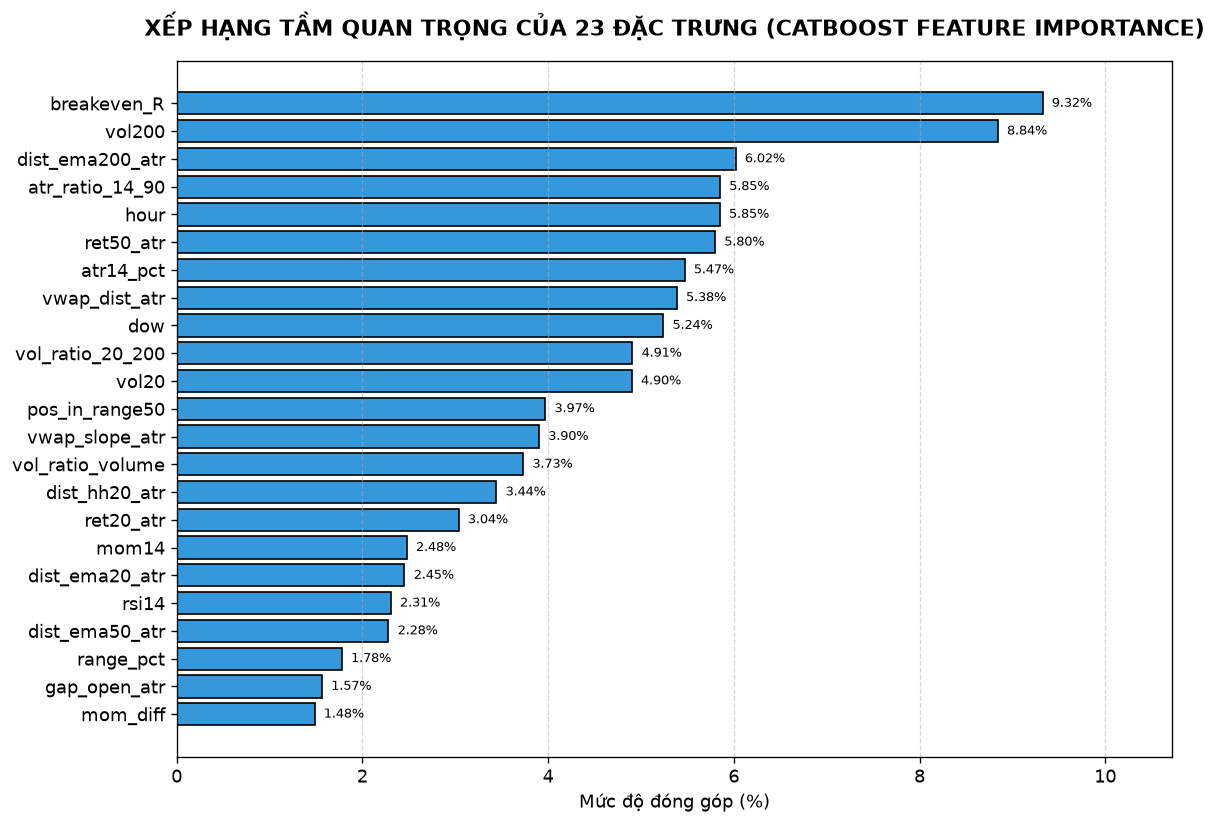

Mô hình dùng cho Feature Importance: outputs/holdout/stage2/catboost_final_holdout_run1.cbm
5 đặc trưng đóng góp cao nhất: hour, atr_ratio_14_90, dist_ema200_atr, vol200, breakeven_R
Tổng Feature Importance = 100.0 (đã chuẩn hóa 100%)


In [7]:
# Nạp mô hình CatBoost chính thức (giai đoạn holdout) và xem Feature Importance
holdout_model = CatBoostClassifier()
holdout_model.load_model(str(HOLDOUT_MODEL_CBM))

# Lấy tên đặc trưng theo đúng thứ tự mô hình đã học, thay vì giả định vị trí.
model_feature_names = list(holdout_model.feature_names_)
if model_feature_names != FEATURES:
    raise ValueError(
        'Thứ tự đặc trưng của mô hình .cbm không khớp FEATURES:\n'
        f'  model: {model_feature_names}\n  FEATURES: {FEATURES}'
    )

importances = holdout_model.get_feature_importance()
feat_imp = (pd.DataFrame({'Feature': model_feature_names,
                          'Importance (%)': importances})
            .sort_values('Importance (%)', ascending=True))

plt.figure(figsize=(10, 7), dpi=120)
bars = plt.barh(feat_imp['Feature'], feat_imp['Importance (%)'], color='#3498DB', edgecolor='black')
plt.xlabel('Mức độ đóng góp (%)')
plt.title('XẾP HẠNG TẦM QUAN TRỌNG CỦA 23 ĐẶC TRƯNG (CATBOOST FEATURE IMPORTANCE)',
             fontweight='bold', pad=15)
plt.grid(axis='x', linestyle='--', alpha=0.5)

for bar in bars:
    w = bar.get_width()
    plt.text(w + 0.1, bar.get_y() + bar.get_height() / 2, f'{w:.2f}%', va='center', fontsize=8)

plt.xlim(0, max(feat_imp['Importance (%)']) * 1.15)
plt.tight_layout()
plt.show()

print('Mô hình dùng cho Feature Importance: ' + str(HOLDOUT_MODEL_CBM.relative_to(ROOT)))
print('5 đặc trưng đóng góp cao nhất: ' + ', '.join(feat_imp['Feature'].tail(5).tolist()))
print('Tổng Feature Importance =', round(float(feat_imp['Importance (%)'].sum()), 4), '(đã chuẩn hóa 100%)')


In [8]:
# Đối chứng 3 mô hình trên CÙNG một cửa sổ kiểm định: train Khúc 1-4, test Khúc 5
# (bước cuối của Walk-Forward — ngoài mẫu cho cả ba mô hình).
from citd_ml.training.train_catboost import MODEL_PARAMS

train_idx = np.concatenate(chunks[:4])   # Khúc 1, 2, 3, 4
test_idx = chunks[4]                    # Khúc 5

X_tr, y_tr = X_all.iloc[train_idx], y_all.iloc[train_idx]
X_te, y_te = X_all.iloc[test_idx], y_all.iloc[test_idx]

print(f'Tập huấn luyện : {len(X_tr):,} dòng (Khúc 1-4), tỷ lệ nhãn=1: {y_tr.mean():.2%}')
print(f'Tập kiểm định : {len(X_te):,} dòng (Khúc 5),   tỷ lệ nhãn=1: {y_te.mean():.2%}')

# 1. Logistic Regression — chuẩn hóa đặc trưng trước (các đặc trưng có thang khác nhau)
#    nên không chuẩn hóa sẽ khiến L2 regularization bóp méo hệ số.
lr = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=5000, class_weight='balanced', random_state=42)),
])
lr.fit(X_tr, y_tr)
p_lr = lr.predict_proba(X_te)[:, 1]

# 2. Random Forest — n_jobs=1 để không phụ thuộc số luồng CPU của máy.
rf = RandomForestClassifier(n_estimators=100, max_depth=6, class_weight='balanced',
                             random_state=42, n_jobs=1)
rf.fit(X_tr, y_tr)
p_rf = rf.predict_proba(X_te)[:, 1]

# 3. CatBoost — đúng bộ tham số đóng băng của dự án. `verbose=False` chỉ tắt log
#    tiến trình 1000 vòng lặp, không thay đổi kết quả mô hình.
cb = CatBoostClassifier(**{**MODEL_PARAMS, 'verbose': False})
cb.fit(X_tr, y_tr)
p_cb = cb.predict_proba(X_te)[:, 1]

print('Ba mô hình đã huấn luyện xong trên cùng ' + f'{len(X_tr):,}' + ' dòng.')

# --- Kiểm tra tính nhất quán với OOF đã commit -------------------------------
# OOF Cách 2 (Walk-Forward) fold 4 chính là: train Khúc 1-4, test Khúc 5.
# Nếu pipeline của notebook khớp pipeline của dự án thì xác suất phải trùng tuyệt đối.
oof_wf = pd.read_csv(CANONICAL_OOF_DIR / 'oof_walk_forward.csv')
oof_wf_fold4 = oof_wf.loc[oof_wf['fold'] == 4].sort_values('row_id')
if not np.array_equal(oof_wf_fold4['row_id'].to_numpy(), test_idx):
    raise ValueError('OOF fold 4 không khớp với Khúc 5')
_max_diff = float(np.max(np.abs(p_cb - oof_wf_fold4['probability'].to_numpy())))
print(f'\nĐối chiếu OOF Cách 2 (fold 4): max|sai khác xác suất| = {_max_diff:.3g}')
if _max_diff > 1e-9:
    raise ValueError('Dựng lại CatBoost không khớp OOF đã commit — kiểm tra lại tham số/chunk')
print(f'=> Notebook tái lập kết quả đã commit; ROC-AUC trùng ở '
      f'{roc_auc_score(y_te, p_cb):.4f} (sai khác chỉ ở mức số thực IEEE-754).')

def get_metrics(y_true, proba):
    pred = (proba >= 0.5).astype(int)
    return {
        'Accuracy': f'{accuracy_score(y_true, pred) * 100:.2f}%',
        'Precision': f'{precision_score(y_true, pred, zero_division=0) * 100:.2f}%',
        'Recall': f'{recall_score(y_true, pred, zero_division=0) * 100:.2f}%',
        'F1-Score': f'{f1_score(y_true, pred, zero_division=0):.4f}',
        'ROC-AUC': f'{roc_auc_score(y_true, proba):.4f}',
    }

models_comparison = pd.DataFrame([
    {'Mô hình': 'Logistic Regression (Linear Baseline)', **get_metrics(y_te, p_lr)},
    {'Mô hình': 'Random Forest (Bagging Ensemble)', **get_metrics(y_te, p_rf)},
    {'Mô hình': 'CatBoost (Đề xuất của nhóm)', **get_metrics(y_te, p_cb)},
])
print('\nBẢNG ĐỐI CHỨNG HIỆU NĂNG 3 MÔ HÌNH TRÊN KHÚC 5 (ngoài mẫu cho cả ba):')
display(models_comparison)

print('\nLưu ý: CatBoost thắng rõ về ROC-AUC (thứ hạng đối với khả năng xếp hạng tín hiệu) nhưng')
print('không thắng về F1@0.5 — ở ngưỡng cắt cứng 0.5 nó bỏ sót nhiều lệnh thắng hơn. Đây cũng là lý do')
print('dự án dùng cách lọc theo phân vị (top 50%) thay vì ngưỡng tuyệt đối. Xem PHẦN 4 và 6.')


Tập huấn luyện : 20,006 dòng (Khúc 1-4), tỷ lệ nhãn=1: 26.47%
Tập kiểm định : 5,002 dòng (Khúc 5),   tỷ lệ nhãn=1: 24.91%
Ba mô hình đã huấn luyện xong trên cùng 20,006 dòng.

Đối chiếu OOF Cách 2 (fold 4): max|sai khác xác suất| = 5e-13
=> Notebook tái lập kết quả đã commit; ROC-AUC trùng ở 0.6293 (sai khác chỉ ở mức số thực IEEE-754).

BẢNG ĐỐI CHỨNG HIỆU NĂNG 3 MÔ HÌNH TRÊN KHÚC 5 (ngoài mẫu cho cả ba):


,Mô hình,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression (Linear Baseline),45.94%,28.52%,77.69%,0.4172,0.6068
1,Random Forest (Bagging Ensemble),55.76%,31.50%,66.05%,0.4265,0.6277
2,CatBoost (Đề xuất của nhóm),65.99%,36.10%,47.43%,0.4100,0.6293



Lưu ý: CatBoost thắng rõ về ROC-AUC (thứ hạng đối với khả năng xếp hạng tín hiệu) nhưng
không thắng về F1@0.5 — ở ngưỡng cắt cứng 0.5 nó bỏ sót nhiều lệnh thắng hơn. Đây cũng là lý do
dự án dùng cách lọc theo phân vị (top 50%) thay vì ngưỡng tuyệt đối. Xem PHẦN 4 và 6.


---
## PHẦN 4: BẢNG ĐỐI SOÁT ĐẮT GIÁ NHẤT CỦA ĐỀ TÀI
So sánh mức độ sai lệch điểm số kiểm định giữa **4 cách chia dữ liệu** và đối chứng với **Tập Holdout niêm phong thực tế**.

**Quy ước đọc bảng (quan trọng).** Cột *ROC-AUC / F1* ở Bảng 1 là **trung bình theo fold** trên các dòng thuộc Khúc 2–5, tức là đã **loại bỏ Khúc 1** (dùng Khúc 1 làm dữ liệu huấn luyện ban đầu nên không thể đánh giá ngoài mẫu trên chính nó). Đây đúng là định nghĩa mà `scripts/holdout_stage4_report.py` dùng để sinh ra bảng, nên con số ở đây khớp 4 chữ số thập phân với `outputs/holdout/stage4/table1_classification_metrics.csv`.

Vì thế **không được** so sánh trực tiếp với `metrics_summary.csv` (trung bình cả 5 fold, gồm Khúc 1) — đó là hai đại lượng khác nhau.


In [9]:
# Tải kết quả OOF chính thức của 4 cách chia (từ cây canonical của dự án)
table1 = pd.read_csv(STAGE4_DIR / 'table1_classification_metrics.csv')
table2 = pd.read_csv(STAGE4_DIR / 'table2_financial_metrics_top50.csv')

# Lọc nhánh chuẩn canonical_thread_count_1 và chunk2_5_thread_count_1
t1_sub = table1.loc[table1['block'] == 'canonical_thread_count_1'].copy()
t2_sub = table2.loc[table2['block'].isin(['chunk2_5_thread_count_1', 'holdout'])].copy()

# Hai cột này được lưu dạng chuỗi có dấu phân cách nghìn và dấu cộng để dễ đọc
# ('20,007', '+3,358.25'). Chuyển về số để bảng dùng được cho tính toán.
def to_number(series: pd.Series) -> pd.Series:
    return pd.to_numeric(
        series.astype(str).str.replace(',', '', regex=False).str.strip().str.lstrip('+'),
        errors='raise',
    )

for _col in ('roc_auc', 'f1_at_0_5'):
    t1_sub[_col] = to_number(t1_sub[_col])
for _col in ('trades', 'net_profit_R', 'max_dd_R', 'profit_factor', 'win_rate_pct'):
    t2_sub[_col] = to_number(t2_sub[_col])

# Chuẩn hóa tên phương pháp để ghép nối đối soát chính xác
method_map_t1 = {
    'random_kfold': '1. Random K-Fold (Rò rỉ 2 chiều)',
    'grouped_kfold': '1b. Grouped K-Fold (Rò rỉ tương lai)',
    'walk_forward': '2. Walk-Forward (Tuần tự thời gian)',
    'purged_walk_forward': '3. Purged Walk-Forward (Khử rò rỉ triệt để)',
    'holdout': 'Holdout - Meta-Labeling (Top 50%)',
}

method_map_t2 = {
    'baseline': '0. Baseline (Khúc 2-5, Chưa lọc ML)',
    'random_kfold': '1. Random K-Fold (Rò rỉ 2 chiều)',
    'grouped_kfold': '1b. Grouped K-Fold (Rò rỉ tương lai)',
    'walk_forward': '2. Walk-Forward (Tuần tự thời gian)',
    'purged_walk_forward': '3. Purged Walk-Forward (Khử rò rỉ triệt để)',
    'baseline_holdout': 'Holdout - Baseline (Chưa lọc ML)',
    'top_50': 'Holdout - Meta-Labeling (Top 50%)',
}

t1_sub['Phuong_Phap'] = t1_sub['method'].map(method_map_t1)
t2_sub['Phuong_Phap'] = t2_sub['method'].map(method_map_t2)

if t1_sub['Phuong_Phap'].isna().any() or t2_sub['Phuong_Phap'].isna().any():
    raise ValueError('Có phương pháp trong bảng gốc chưa được ánh xạ tên')

summary_df = pd.merge(
    t2_sub[['Phuong_Phap', 'trades', 'net_profit_R', 'max_dd_R', 'profit_factor',
             'win_rate_pct']],
    t1_sub[['Phuong_Phap', 'roc_auc', 'f1_at_0_5']],
    on='Phuong_Phap',
    how='left',
)

summary_df = summary_df.rename(columns={
    'Phuong_Phap': 'Phương pháp / Tập kiểm định',
    'roc_auc': 'ROC-AUC',
    'f1_at_0_5': 'F1-Score (@0.5)',
    'trades': 'Số lệnh',
    'net_profit_R': 'Lợi nhuận ròng (R)',
    'max_dd_R': 'Max DD (R)',
    'profit_factor': 'Profit Factor',
    'win_rate_pct': 'Tỷ lệ thắng (%)',
})

cols_order = ['Phương pháp / Tập kiểm định', 'ROC-AUC', 'F1-Score (@0.5)',
              'Số lệnh', 'Tỷ lệ thắng (%)', 'Profit Factor',
              'Lợi nhuận ròng (R)', 'Max DD (R)']

# Baseline chưa qua bộ lọc nên không có ROC-AUC/F1; Holdout baseline chỉ có số tài chính.
summary_df = summary_df.loc[:, cols_order]
FMT = {'Số lệnh': ',.0f', 'Tỷ lệ thắng (%)': ',.2f', 'Profit Factor': ',.4f',
       'Lợi nhuận ròng (R)': '+,.2f', 'Max DD (R)': ',.2f',
       'ROC-AUC': '.4f', 'F1-Score (@0.5)': '.4f'}
for _col in cols_order[1:]:
    summary_df[_col] = summary_df[_col].map(
        lambda v: '-' if pd.isna(v) else format(v, FMT[_col])
    )

print('=' * 100)
print('BẢNG ĐỐI SOÁT ĐẮT GIÁ: ĐỘ TIN CẬY CỦA 4 CÁCH CHIA DỮ LIỆU VÀ KIỂM ĐỊNH HOLDOUT NIÊM PHONG')
print('=' * 100)
display(summary_df.set_index('Phương pháp / Tập kiểm định'))

print('Đọc bảng: Random K-Fold cho ROC-AUC 0.8582 nhưng giảm MaxDD mạnh nhất — đó chính là dấu hiệu')
print('rò rỉ (anh em lệnh cùng origin_bar nằm ở cả train và test). Khi kiểm định trên dữ liệu tương lai')
print('niêm phong, mọi cách chia hội tụ về nhau quanh 0.59-0.60.')


BẢNG ĐỐI SOÁT ĐẮT GIÁ: ĐỘ TIN CẬY CỦA 4 CÁCH CHIA DỮ LIỆU VÀ KIỂM ĐỊNH HOLDOUT NIÊM PHONG


,ROC-AUC,F1-Score (@0.5),Số lệnh,Tỷ lệ thắng (%),Profit Factor,Lợi nhuận ròng (R),Max DD (R)
Phương pháp / Tập kiểm định,,,,,,,
"0. Baseline (Khúc 2-5, Chưa lọc ML)",-,-,"20,007",31.71,1.2940,"+3,358.25",236.13
1. Random K-Fold (Rò rỉ 2 chiều),0.8582,0.6494,"10,004",44.65,2.5437,"+6,937.53",73.76
1b. Grouped K-Fold (Rò rỉ tương lai),0.7454,0.5077,"10,004",39.26,1.9500,"+4,752.04",99.71
2. Walk-Forward (Tuần tự thời gian),0.5875,0.3288,"10,004",34.76,1.4117,"+2,148.31",211.29
3. Purged Walk-Forward (Khử rò rỉ triệt để),0.5895,0.3247,"10,004",34.99,1.4074,"+2,119.48",142.36
Holdout - Baseline (Chưa lọc ML),-,-,"5,028",35.28,1.0992,+245.93,305.32
Holdout - Meta-Labeling (Top 50%),0.6046,0.4022,"2,514",34.81,0.9718,-36.55,263.25


Đọc bảng: Random K-Fold cho ROC-AUC 0.8582 nhưng giảm MaxDD mạnh nhất — đó chính là dấu hiệu
rò rỉ (anh em lệnh cùng origin_bar nằm ở cả train và test). Khi kiểm định trên dữ liệu tương lai
niêm phong, mọi cách chia hội tụ về nhau quanh 0.59-0.60.


Đối chiếu AUC tính ở đây với Bảng 1 (canonical_thread_count_1):
  Cách 1 — Random K-Fold       0.8582  ✓ khớp Bảng 1
  Cách 1b — Grouped K-Fold     0.7454  ✓ khớp Bảng 1
  Cách 2 — Walk-Forward        0.5875  ✓ khớp Bảng 1
  Cách 3 — WF + Purge/Embargo  0.5895  ✓ khớp Bảng 1
  Holdout Niêm Phong           0.6046  ✓ khớp Bảng 1


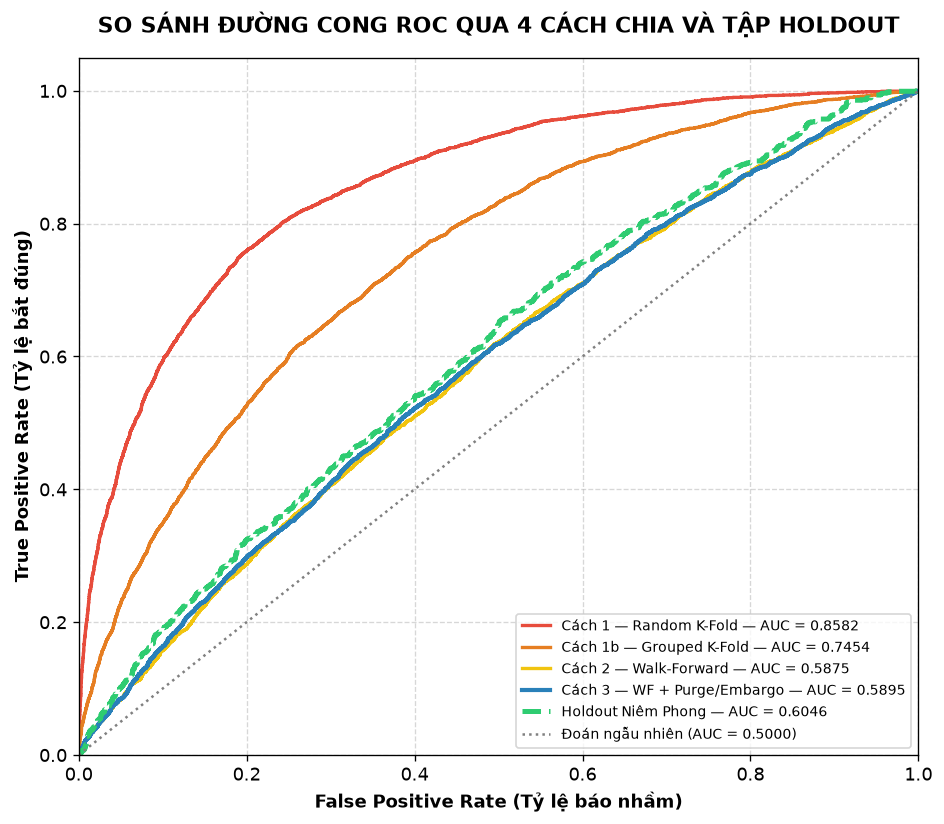

Ghi chú: đường cong được vẽ trên toàn bộ dòng Khúc 2-5, còn số AUC trong chú giải là
trung bình theo fold — cùng định nghĩa với Bảng 1 nên hai nơi luôn khớp nhau.


In [10]:
# Đường cong ROC đối sánh 4 cách chia và tập Holdout
#
# Định nghĩa dùng ở đây **giống hệt** Bảng 1: giữ các dòng có fold >= 1 VÀ chunk != 1
# (chunk tính từ row_id theo biên [5001, 10003, 15004, 20006, 25008]), rồi lấy TRUNG BÌNH
# ROC-AUC theo từng fold. Ô này tự kiểm tra lại kết quả đó khớp table1 trước khi vẽ.
CHUNK_EDGES_FOR_FOLD = chunk_edges[1:]  # [5001, 10003, 15004, 20006, 25008]

def canonical_fold_metrics(method: str) -> tuple[pd.DataFrame, float]:
    """Trả về (dữ liệu để vẽ ROC, trung bình ROC-AUC theo fold) theo đúng định nghĩa Bảng 1."""
    frame = pd.read_csv(CANONICAL_OOF_DIR / f'oof_{method}.csv')
    chunk = 1 + np.searchsorted(CHUNK_EDGES_FOR_FOLD, frame['row_id'].to_numpy(), side='right')
    kept = frame.loc[(frame['fold'] >= 1) & (chunk != 1)]
    if kept.empty:
        raise ValueError(f'Không còn dòng nào sau khi bỏ Khúc 1 cho {method}')
    aucs = [roc_auc_score(g[TARGET], g['probability']) for _, g in kept.groupby('fold', sort=True)]
    return kept, float(np.mean(aucs))

methods = [
    ('random_kfold', 'Cách 1 — Random K-Fold', '#E74C3C', 2),
    ('grouped_kfold', 'Cách 1b — Grouped K-Fold', '#E67E22', 2),
    ('walk_forward', 'Cách 2 — Walk-Forward', '#F1C40F', 2),
    ('purged_walk_forward', 'Cách 3 — WF + Purge/Embargo', '#2980B9', 2.5),
]

plt.figure(figsize=(8, 7), dpi=120)
print('Đối chiếu AUC tính ở đây với Bảng 1 (canonical_thread_count_1):')

for method, label, color, lw in methods:
    df_sub, auc = canonical_fold_metrics(method)
    fpr, tpr, _ = roc_curve(df_sub[TARGET], df_sub['probability'])
    plt.plot(fpr, tpr, color=color, lw=lw,
             label=f'{label} — AUC = {auc:.4f}')
    expected = float(t1_sub.loc[t1_sub['method'] == method, 'roc_auc'].iloc[0])
    if abs(auc - expected) > 5e-5:
        raise ValueError(f'{method}: AUC {auc:.6f} lệch Bảng 1 ({expected:.6f})')
    print(f'  {label:<28} {auc:.4f}  ✓ khớp Bảng 1')

# Holdout: một tập duy nhất, ROC-AUC tính trực tiếp (không trung bình fold)
auc_h = roc_auc_score(df_holdout[TARGET], df_holdout['probability'])
expected_h = float(t1_sub.loc[t1_sub['method'] == 'holdout', 'roc_auc'].iloc[0])
if abs(auc_h - expected_h) > 5e-5:
    raise ValueError(f'Holdout: AUC {auc_h:.6f} lệch Bảng 1 ({expected_h:.6f})')
fpr_h, tpr_h, _ = roc_curve(df_holdout[TARGET], df_holdout['probability'])
plt.plot(fpr_h, tpr_h, color='#2ECC71', lw=3, linestyle='--',
         label=f'Holdout Niêm Phong — AUC = {auc_h:.4f}')
print(f'  {"Holdout Niêm Phong":<28} {auc_h:.4f}  ✓ khớp Bảng 1')

plt.plot([0, 1], [0, 1], color='gray', linestyle=':', label='Đoán ngẫu nhiên (AUC = 0.5000)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Tỷ lệ báo nhầm)', fontweight='bold')
plt.ylabel('True Positive Rate (Tỷ lệ bắt đúng)', fontweight='bold')
plt.title('SO SÁNH ĐƯỜNG CONG ROC QUA 4 CÁCH CHIA VÀ TẬP HOLDOUT', fontweight='bold', pad=15)
plt.legend(loc='lower right', fontsize=8.5)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print('Ghi chú: đường cong được vẽ trên toàn bộ dòng Khúc 2-5, còn số AUC trong chú giải là')
print('trung bình theo fold — cùng định nghĩa với Bảng 1 nên hai nơi luôn khớp nhau.')


---
## PHẦN 5: ĐÁNH GIÁ HIỆU QUẢ TÀI CHÍNH & ĐƯỜNG CONG VỐN
Đánh giá lợi nhuận ròng ($R$), Mức sụt giảm tối đa (Max Drawdown) và hiển thị lại biểu đồ đường cong vốn (Equity Curve) chuẩn xác từng bước.

Các con số tài chính ở đây **không được huấn luyện lại** — chúng đọc thẳng từ kết quả đã commit của Stage 3/4, đúng như giới hạn mà README ghi rõ (đánh giá holdout đã đóng ngày 2026-09-18).


1. Biểu đồ đường cong vốn trên tập phát triển (Khúc 2–5, Top 50%)


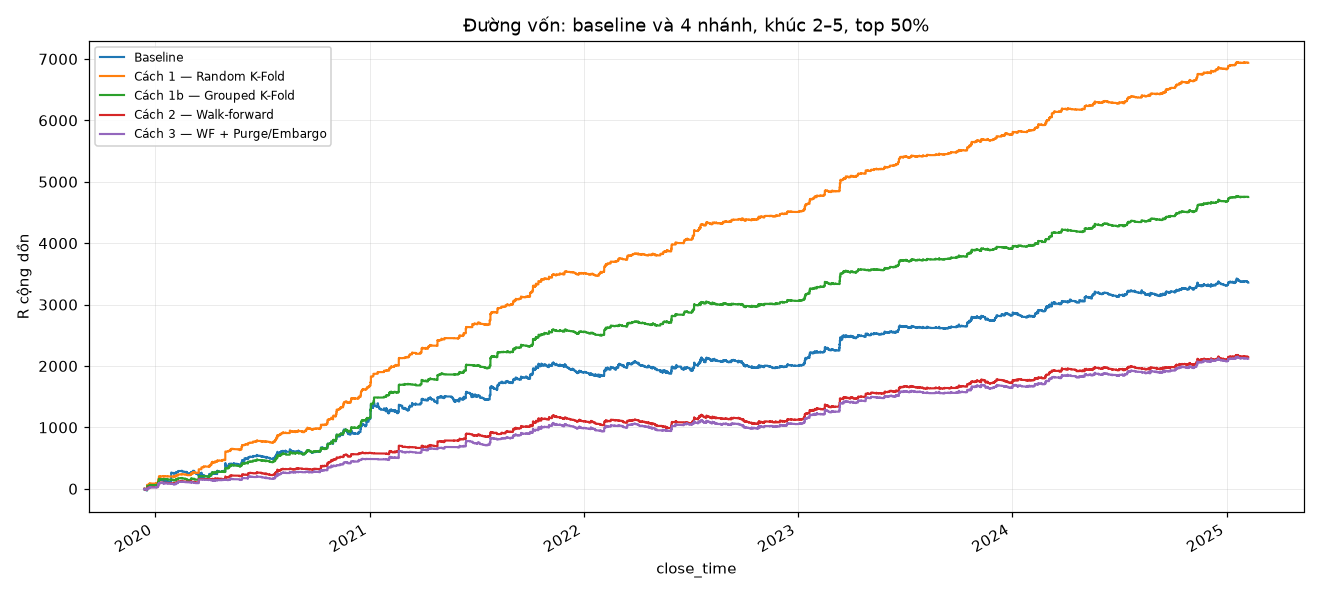

2. Biểu đồ đường cong vốn trên tập Holdout niêm phong (Top 50%)


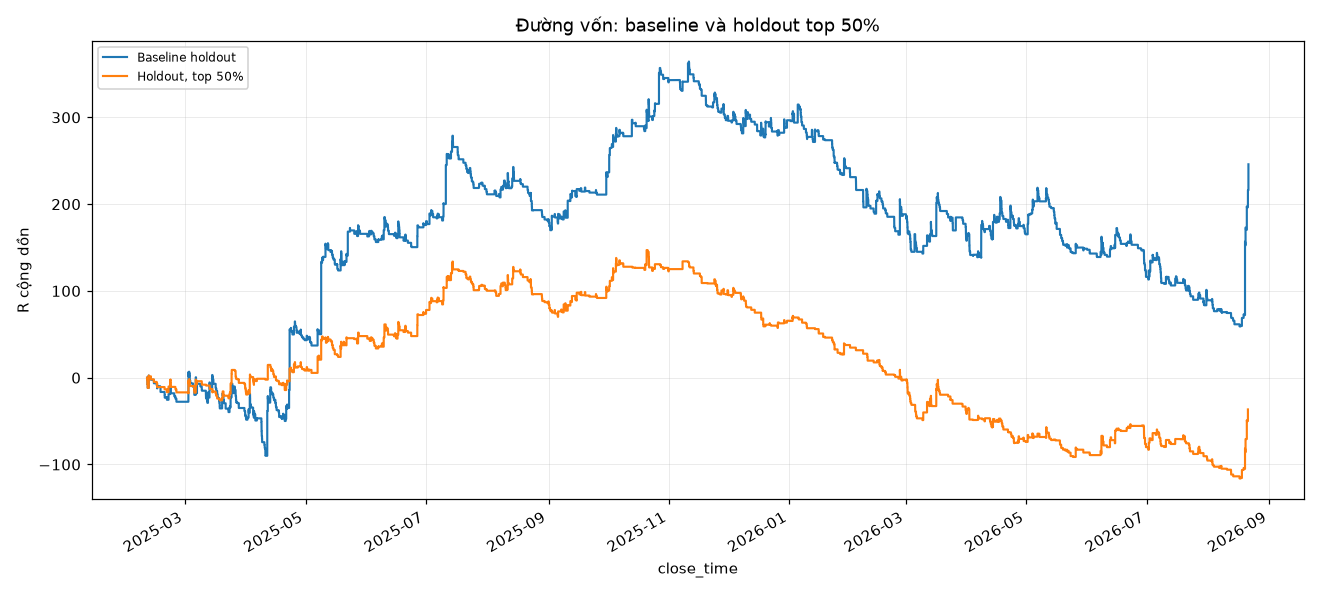

Lưu ý: biểu đồ 2 cho thấy đường cong vốn đi ngang/sụt nhẹ ở Holdout — đây là kết quả thực,
không phải lỗi vẽ. Xem PHẦN 7 để hiểu vì sao kết luận tài chính phải thận trọng.


In [11]:
# Hiển thị biểu đồ đường cong vốn đã xuất từ quy trình
for _title, _file in [
    ('1. Biểu đồ đường cong vốn trên tập phát triển (Khúc 2–5, Top 50%)',
     'equity-curve-chunk2-5-top50.png'),
    ('2. Biểu đồ đường cong vốn trên tập Holdout niêm phong (Top 50%)',
     'equity-curve-holdout-top50.png'),
]:
    _path = STAGE4_DIR / _file
    if not _path.is_file():
        raise FileNotFoundError(f'Thiếu biểu đồ: {_path}')
    print(_title)
    display(Image(filename=str(_path)))

print('Lưu ý: biểu đồ 2 cho thấy đường cong vốn đi ngang/sụt nhẹ ở Holdout — đây là kết quả thực,')
print('không phải lỗi vẽ. Xem PHẦN 7 để hiểu vì sao kết luận tài chính phải thận trọng.')


---
## PHẦN 6: MA TRẬN NHẦM LẪN (CONFUSION MATRIX) & PHÂN TÍCH SAI SỐ
Phân tích chi tiết hai loại lỗi:
* **False Positive (Báo nhầm):** Dự đoán thắng nhưng thực tế chạm Stop-Loss $\rightarrow$ Gây tổn thất vốn.
* **False Negative (Bỏ sót):** Dự đoán thua nhưng thực tế chạm Take-Profit $\rightarrow$ Bỏ lỡ cơ hội nhưng bảo toàn vốn an toàn.

Ma trận dưới đây được tính trên **toàn bộ 5.028 mẫu holdout** ở ngưỡng 0.5. Nhớ rằng ở ngưỡng 0.5, lớp 1 bị dự đoán thiếu rất nhiều — vì vậy *Recall* thấp là đặc tính của cách chấm điểm này, **không** phải lỗi mô hình. Chiến lược thực tế của dự án không dùng ngưỡng 0.5, mà **loại bỏ 50% lệnh có điểm thấp nhất** (xem PHẦN 4).


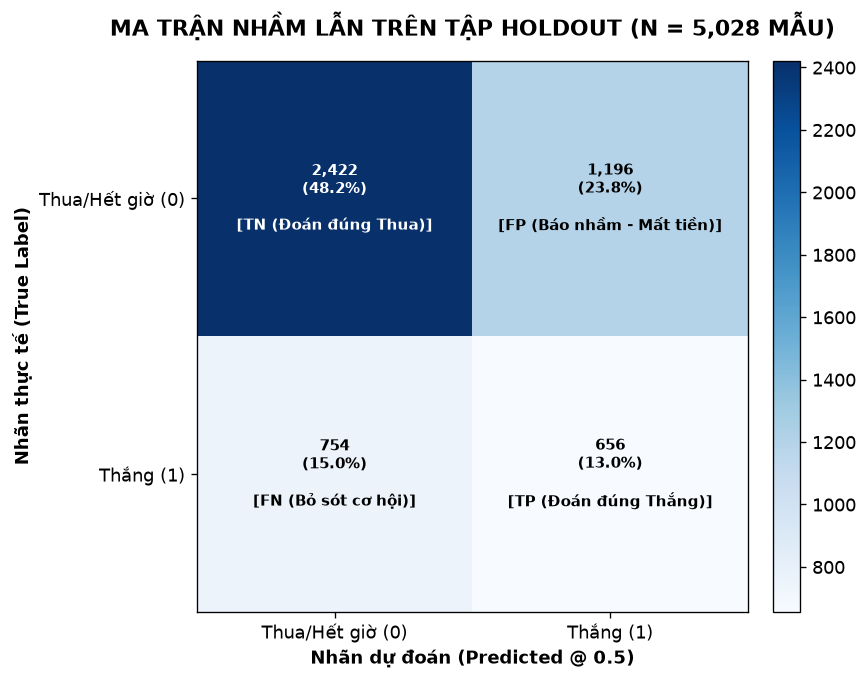

Tỷ lệ nhãn=1 thực tế trên holdout: 28.04%
Recall@0.5 = 46.52%  ->  chỉ bắt được 46.5% số lệnh thắng.
Đây là hệ quả của ngưỡng 0.5 trên dữ liệu mất cân bằng, không phải lỗi mô hình: dùng
ngưỡng này như một bộ lọc cứng thì tệ hơn cả giữ nguyên toàn bộ lệnh (xem PHẦN 4).


In [12]:
# Trực quan hóa Ma trận nhầm lẫn trên tập Holdout (5.028 mẫu)
y_true = df_holdout[TARGET].to_numpy()
y_pred = (df_holdout['probability'].to_numpy() >= 0.5).astype(int)
cm = confusion_matrix(y_true, y_pred)
total = len(y_true)

fig, ax = plt.subplots(figsize=(7.0, 5.8), dpi=120)
cax = ax.imshow(cm, cmap=plt.cm.Blues)
plt.colorbar(cax, fraction=0.046, pad=0.04)

classes = ['Thua/Hết giờ (0)', 'Thắng (1)']
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(classes, fontsize=11)
ax.set_yticklabels(classes, fontsize=11)

thresh = cm.max() / 2.
labels_desc = [
    ['TN (Đoán đúng Thua)', 'FP (Báo nhầm - Mất tiền)'],
    ['FN (Bỏ sót cơ hội)', 'TP (Đoán đúng Thắng)'],
]
for i in range(2):
    for j in range(2):
        val = cm[i, j]
        pct = val / total * 100
        desc = labels_desc[i][j]
        color = 'white' if val > thresh else 'black'
        ax.text(j, i, f'{val:,}\n({pct:.1f}%)\n\n[{desc}]',
                ha='center', va='center', color=color, fontsize=9, fontweight='bold')

ax.set_ylabel('Nhãn thực tế (True Label)', fontweight='bold')
ax.set_xlabel('Nhãn dự đoán (Predicted @ 0.5)', fontweight='bold')
ax.set_title(f'MA TRẬN NHẦM LẪN TRÊN TẬP HOLDOUT (N = {total:,} MẪU)', fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

_recall = recall_score(y_true, y_pred, zero_division=0)
_pos_rate = y_true.mean()
print(f'Tỷ lệ nhãn=1 thực tế trên holdout: {_pos_rate:.2%}')
print(f'Recall@0.5 = {_recall:.2%}  ->  chỉ bắt được {_recall:.1%} số lệnh thắng.')
print('Đây là hệ quả của ngưỡng 0.5 trên dữ liệu mất cân bằng, không phải lỗi mô hình: dùng')
print('ngưỡng này như một bộ lọc cứng thì tệ hơn cả giữ nguyên toàn bộ lệnh (xem PHẦN 4).')


---
## PHẦN 7: KẾT LUẬN & ĐÓNG GÓP CỦA ĐỀ TÀI

### 1. Về mặt hệ thống — kết quả tốt *ở tập phát triển*, và **đó là điều kiện cần*
* Trên tập phát triển (Khúc 2–5), tầng meta-labeling bằng CatBoost giữ lại 50% lệnh có điểm cao nhất và **giảm Max Drawdown từ 236,13 R xuống 142,36 R (giảm ~40%)**, đồng thời nâng tỷ lệ thắng từ 31,71% lên 34,99%.
* **Tuy nhiên trên tập Holdout niêm phong, hiệu ứng này không tái lập:** baseline đạt **+245,93 R** (profit factor 1,099) trong khi bộ lọc top-50% chỉ đạt **−36,55 R** (profit factor 0,972).
* Bài học thu được vì vậy phải được phát biểu thận trọng: **bộ lọc meta-labeling đã hạn chế được rủi ro, nhưng chưa chứng minh được là sinh lời ngoài mẫu.** Chính sự chênh lệch này mới là phát hiện quan trọng nhất của đồ án.

### 2. Về mặt phương pháp luận — kết luận vững nhất của đồ án
* Thực nghiệm cho thấy nếu dùng **Random K-Fold** trên chuỗi thời gian tài chính, điểm kiểm định bị thổi phồng ảo (ROC-AUC = 0,8582 ở tập phát triển).
* Khi áp dụng kỷ luật rò rỉ, các ước lượng **hội tụ về nhau quanh 0,59–0,60**, và giá trị thực tế đo được trên tập tương lai niêm phong là **0,6046** — nằm ngay trong vùng hội tụ đó.
* Nói cách khác: **hai phương pháp nghiêm ngặt (Walk-Forward và Purged Walk-Forward) cho ước lượng trung thực**, còn Random K-Fold cho ước lượng phóng đại. Đây là luận điểm trung tâm và là phần đóng góp bền vững nhất của đồ án, vì nó **không phụ thuộc** vào việc bộ lọc có sinh lời hay không.

### 3. Về tính liêm chính khoa học — nêu đúng mức độ tái lập được
* Toàn bộ mã nguồn ghim `random_seed=42` **và `thread_count=1`**, kèm quy trình băm SHA-256 để kiểm tra tính tái lập.
* **Trên cùng một máy**, hai lần chạy độc lập cho kết quả *giống hệt nhau* (sai khác xác suất tối đa = 0,0; bốn biểu đồ Stage 4 trùng byte).
* **Giữa các máy khác nhau, tính tái lập chưa được chứng minh.** README ghi rõ: đồng nghiệp Windows chỉ báo cáo sai khác ≤ 1e-15 (không trùng byte) mà không kèm tệp kết quả. Thêm nữa, thực nghiệm có kiểm soát trong `outputs/thread_count_sensitivity/` cho thấy đổi `thread_count` khi **huấn luyện** làm thay đổi **mọi** dự đoán trên máy này — mâu thuẫn với tuyên bố của tài liệu CatBoost rằng tham số này không ảnh hưởng kết quả.
* Vì vậy mệnh đề đúng phải là: **tái lập được trên cùng một máy và cùng một cấu hình CatBoost; chưa chứng minh được trên toàn hệ thống.** Notebook này kiểm chứng lại đúng giới hạn đó bằng phép đối chiếu OOF ở PHẦN 3.

---
### Tài liệu tham chiếu kết quả đầy đủ
* Báo cáo tổng hợp holdout: [`docs/BAO_CAO_KET_QUA_HOLDOUT.md`](docs/BAO_CAO_KET_QUA_HOLDOUT.md)
* Báo cáo bước 4: [`docs/BAO_CAO_KET_QUA_STEP4.md`](docs/BAO_CAO_KET_QUA_STEP4.md)
* Lịch sử các lần chạy holdout: [`outputs/verification/holdout_run_history.md`](outputs/verification/holdout_run_history.md)
* Hướng dẫn cài đặt & chạy: [`README.md`](README.md) / [`README_VI.md`](README_VI.md)
